In [1]:
import sys
sys.path.append("../")

from generate_parameter_sample import PARAMETER_RANGES
from utils import *
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import pickle
import os
from scipy.stats import gaussian_kde, pearsonr
from experiment import unpack_and_dequantize

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({"font.size" : 15,
                     "figure.dpi" : 100, 
                     "grid.alpha" : 0.3, 
                     "axes.grid": False, 
                     "axes.axisbelow" : True,
                     "figure.figsize":(8,6),
                     "mathtext.fontset":"cm",
                     "xtick.labelsize": 14,
                     "ytick.labelsize": 14,
                     "axes.labelsize": 16, 
                     "legend.fontsize": 13.5})
plt.rc("text", usetex=False)
plt.rc("font", family="serif")

# EUT Mean Final Utility Phase Space

In [2]:
with open("../data/eut/eut_95/mean_util", "rb") as f:
    U = pickle.load(f)

with open("../data/eut/eut_95/params", "rb") as f:
    data = pickle.load(f)

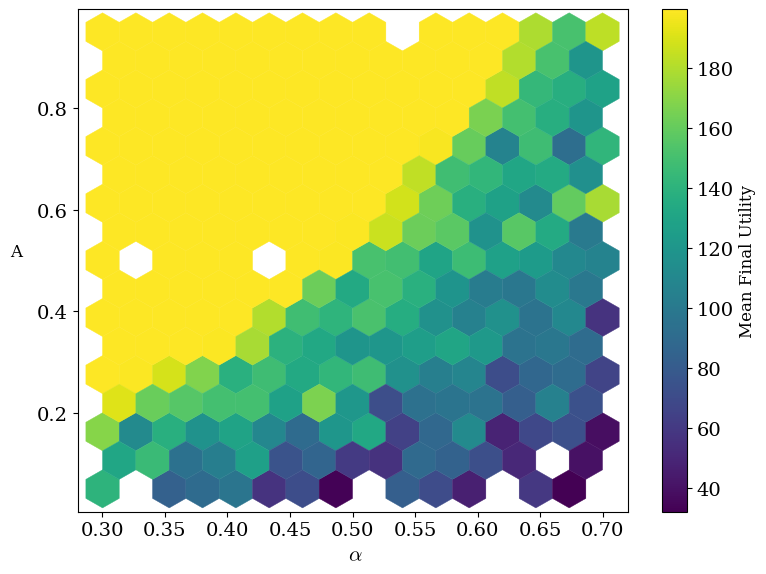

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# Unpack parameters
alphas = [d[0] for d in data]
rates  = [d[1] for d in data]
As     = [d[2] for d in data]

fig, ax = plt.subplots(figsize=(8, 6))

hb = ax.hexbin(
    alphas, 
    As,
    C=U,
    reduce_C_function=np.mean,
    gridsize=15,
    cmap="viridis",
    linewidths=0.3,
    mincnt=1
)

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Mean Final Utility", fontsize=12)

ax.set_xlabel(r" $\alpha$", fontsize=15)
ax.set_ylabel("A", fontsize=12, rotation=0, labelpad=15)

plt.tight_layout()
plt.show()

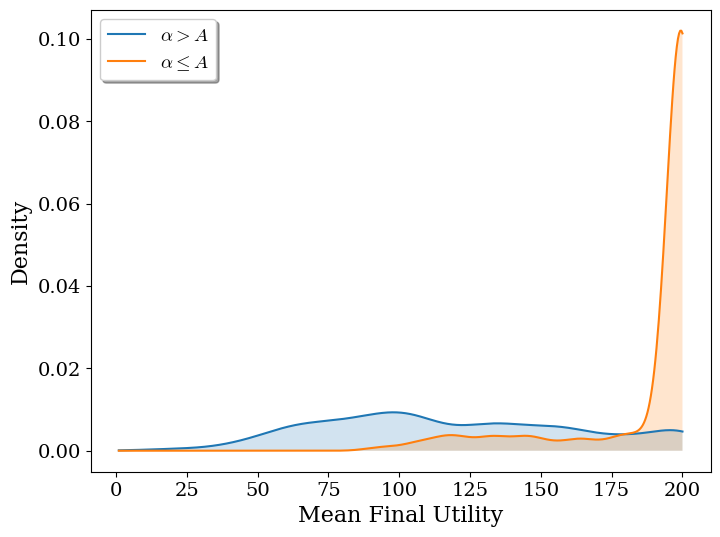

In [5]:
group1 = []
group2 = []
for i,row in enumerate(data):
    if row[0] > row[2]:
        group1.append(U[i])
    else:
        group2.append(U[i])


labels = [r"$\alpha>A$", r"$\alpha\leq A$"]
for i,g in enumerate([group1, group2]):
    kde = gaussian_kde(g, bw_method=0.2)
    x_vals = np.linspace(1, 200, 500)
    y_vals = kde(x_vals)
    y_vals /= np.trapz(y_vals, x_vals)
    plt.plot(x_vals, y_vals, label=labels[i], lw=1.5)
    plt.fill_between(x_vals, y_vals, alpha=0.2)

plt.legend(shadow=True)
plt.xlabel("Mean Final Utility")
plt.ylabel("Density")
plt.savefig("../figures/alpha_A_eut_bifurcation.pdf", bbox_inches="tight")
plt.show()

# CPT

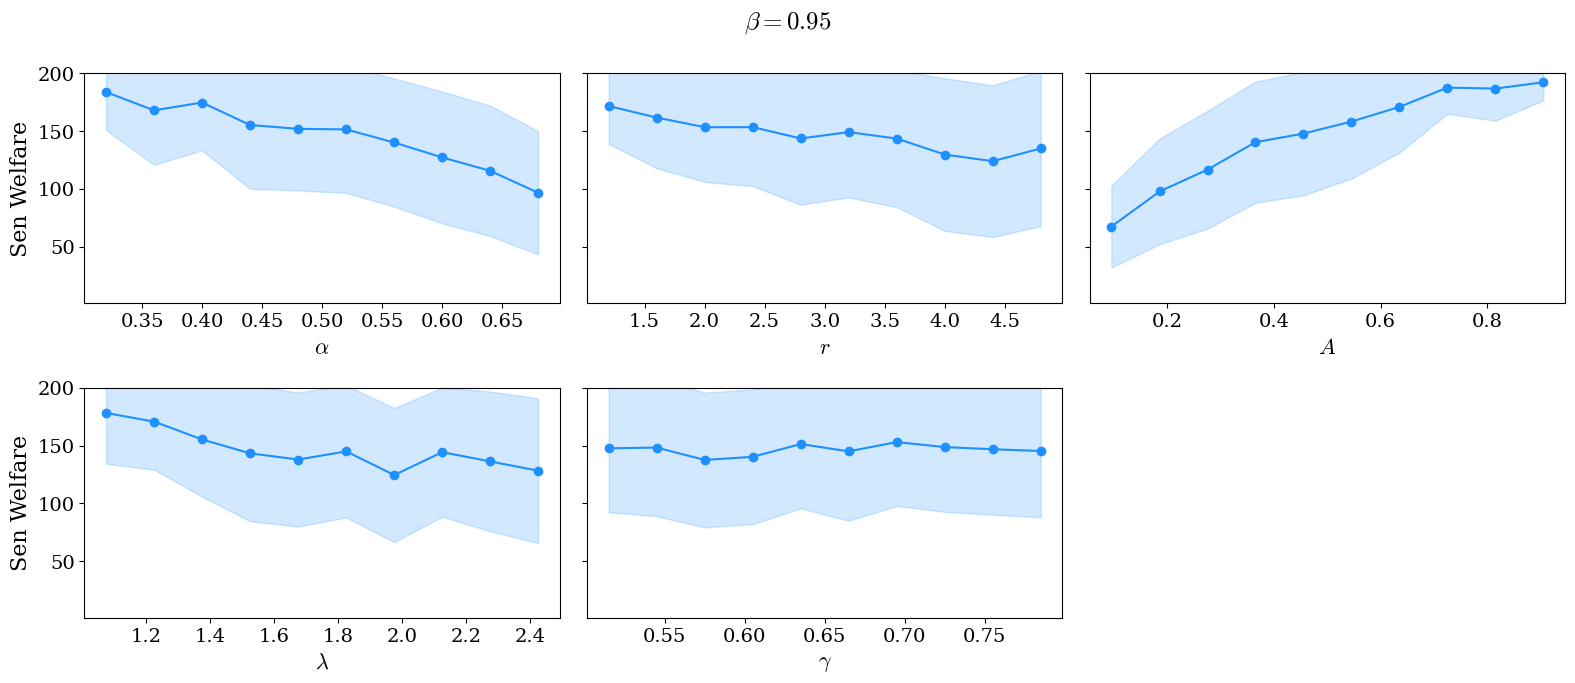

In [60]:
directory = "cpt"
with open(f"../data/cpt/cpt_kt_95/sen_welfare", "rb") as f:
    sen = pickle.load(f)

data = []
with open(f"../data/cpt/cpt_kt_95/params", "rb") as f:
    P = pickle.load(f)
for i,row in enumerate(P):
    data.append((row[0], row[1], row[2], row[3], row[4], sen[i]))

cols = ["alpha", "rate", "A", "lambda", "gamma", "welfare"]
df = pd.DataFrame(data, columns=cols)

nbins = 10
labels = [r"$\alpha$", r"$r$", r"$A$", r"$\lambda$", r"$\gamma$"]
fig, axs = plt.subplots(2, 3, figsize=(16,7), sharey=True)
for i,param in enumerate(cols[:-1]):
    df["bin"] = pd.cut(df[param], bins=nbins)
    group = df.groupby("bin")["welfare"]
    mean_vals = group.mean()
    std_vals = group.std()
    bin_centers = [interval.mid for interval in mean_vals.index]
    axs[int(i/3)][i%3].plot(bin_centers, mean_vals.values, label="Mean Sen Welfare", color="dodgerblue", marker='o')
    axs[int(i/3)][i%3].fill_between(bin_centers,
                    mean_vals - std_vals,
                    mean_vals + std_vals,
                    alpha=0.2,
                    label="± 1 std",
                    color="dodgerblue"
    )
    axs[int(i/3)][i%3].set_xlabel(labels[i])
    axs[int(i/3)][i%3].set_ylim(1,200)

axs[0][0].set_ylabel("Sen Welfare")
axs[1][0].set_ylabel("Sen Welfare")
axs[1][2].set_visible(False)

plt.suptitle(r"$\beta=0.95$")
fig.tight_layout()
#plt.savefig("../figures/cpt_sen_welfare.pdf", bbox_inches="tight")
plt.show()

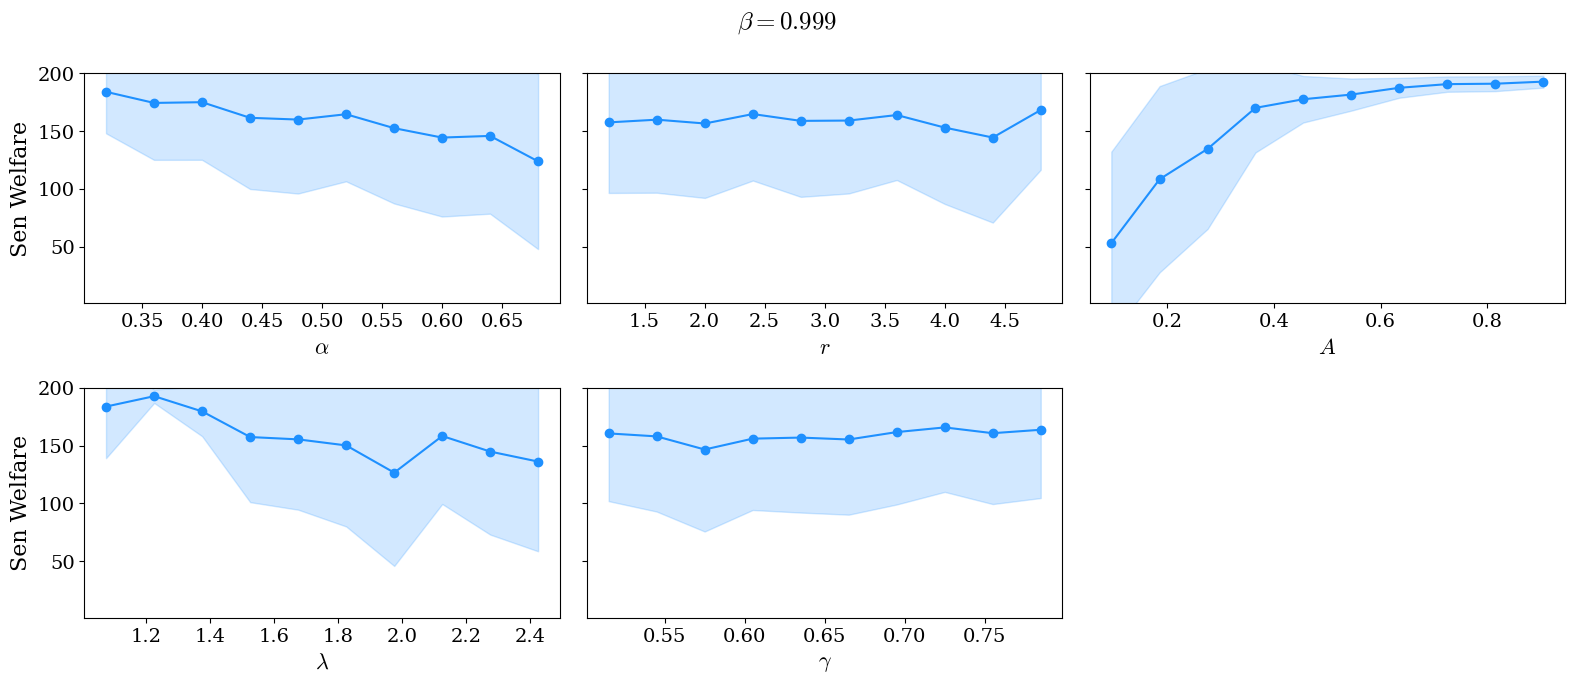

In [58]:
directory = "cpt"
with open(f"../data/cpt/cpt_kt_999/sen_welfare", "rb") as f:
    sen = pickle.load(f)

data = []
with open(f"../data/cpt/cpt_kt_999/params", "rb") as f:
    P = pickle.load(f)
for i,row in enumerate(P):
    data.append((row[0], row[1], row[2], row[3], row[4], sen[i]))

cols = ["alpha", "rate", "A", "lambda", "gamma", "welfare"]
df = pd.DataFrame(data, columns=cols)

nbins = 10
labels = [r"$\alpha$", r"$r$", r"$A$", r"$\lambda$", r"$\gamma$"]
fig, axs = plt.subplots(2, 3, figsize=(16,7), sharey=True)
for i,param in enumerate(cols[:-1]):
    df["bin"] = pd.cut(df[param], bins=nbins)
    group = df.groupby("bin")["welfare"]
    mean_vals = group.mean()
    std_vals = group.std()
    bin_centers = [interval.mid for interval in mean_vals.index]
    axs[int(i/3)][i%3].plot(bin_centers, mean_vals.values, label="Mean Sen Welfare", color="dodgerblue", marker='o')
    axs[int(i/3)][i%3].fill_between(bin_centers,
                    mean_vals - std_vals,
                    mean_vals + std_vals,
                    alpha=0.2,
                    label="± 1 std",
                    color="dodgerblue"
    )
    axs[int(i/3)][i%3].set_xlabel(labels[i])
    axs[int(i/3)][i%3].set_ylim(1,200)

axs[0][0].set_ylabel("Sen Welfare")
axs[1][0].set_ylabel("Sen Welfare")
axs[1][2].set_visible(False)

plt.suptitle(r"$\beta=0.999$")
fig.tight_layout()
#plt.savefig("../figures/cpt_sen_welfare.pdf", bbox_inches="tight")
plt.show()

# PT

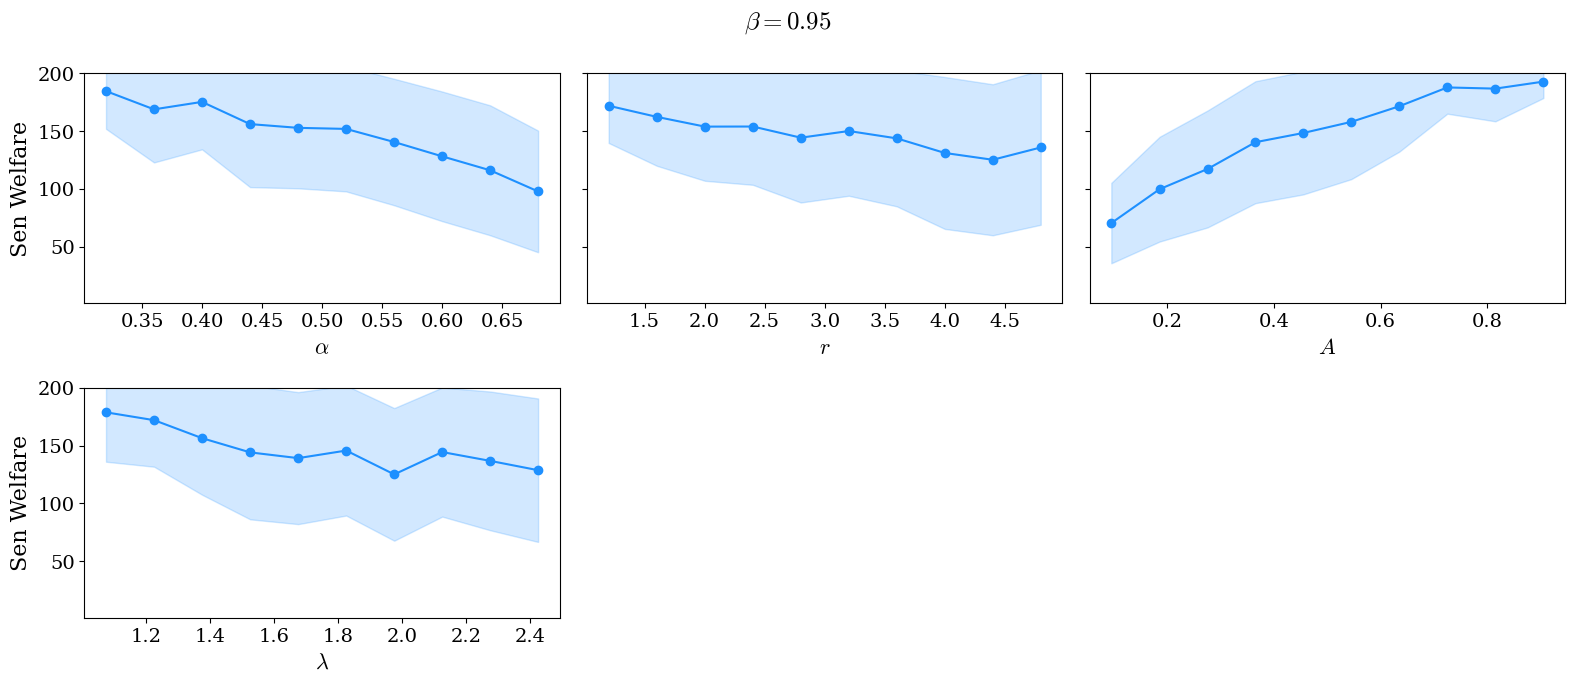

In [54]:
directory = "eut"
with open(f"../data/pt/pt_95/sen_welfare", "rb") as f:
    sen = pickle.load(f)

data = []
with open(f"../data/pt/pt_95/params", "rb") as f:
    P = pickle.load(f)
for i,row in enumerate(P):
    data.append((row[0], row[1], row[2], row[3], sen[i]))


cols = ["alpha", "rate", "A", "lambda", "welfare"]
df = pd.DataFrame(data, columns=cols)

nbins = 10
labels = [r"$\alpha$", r"$r$", r"$A$", r"$\lambda$"]
fig, axs = plt.subplots(2, 3, figsize=(16,7), sharey=True)
for i,param in enumerate(cols[:-1]):
    df["bin"] = pd.cut(df[param], bins=nbins)
    group = df.groupby("bin")["welfare"]
    mean_vals = group.mean()
    std_vals = group.std()
    bin_centers = [interval.mid for interval in mean_vals.index]
    axs[int(i/3)][i%3].plot(bin_centers, mean_vals.values, label="Mean Sen Welfare", color="dodgerblue", marker="o")
    axs[int(i/3)][i%3].fill_between(bin_centers,
                    mean_vals - std_vals,
                    mean_vals + std_vals,
                    alpha=0.2,
                    label="± 1 std",
                    color="dodgerblue"
    )
    axs[int(i/3)][i%3].set_xlabel(labels[i])
    axs[int(i/3)][i%3].set_ylim(1,200)

axs[0][0].set_ylabel("Sen Welfare")
axs[1][0].set_ylabel("Sen Welfare")
axs[1][2].set_visible(False)
axs[1][1].set_visible(False)

plt.suptitle(r"$\beta=0.95$")
fig.tight_layout()
#plt.savefig(f"../figures/{directory}_sen_welfare.pdf", bbox_inches="tight")
plt.show()

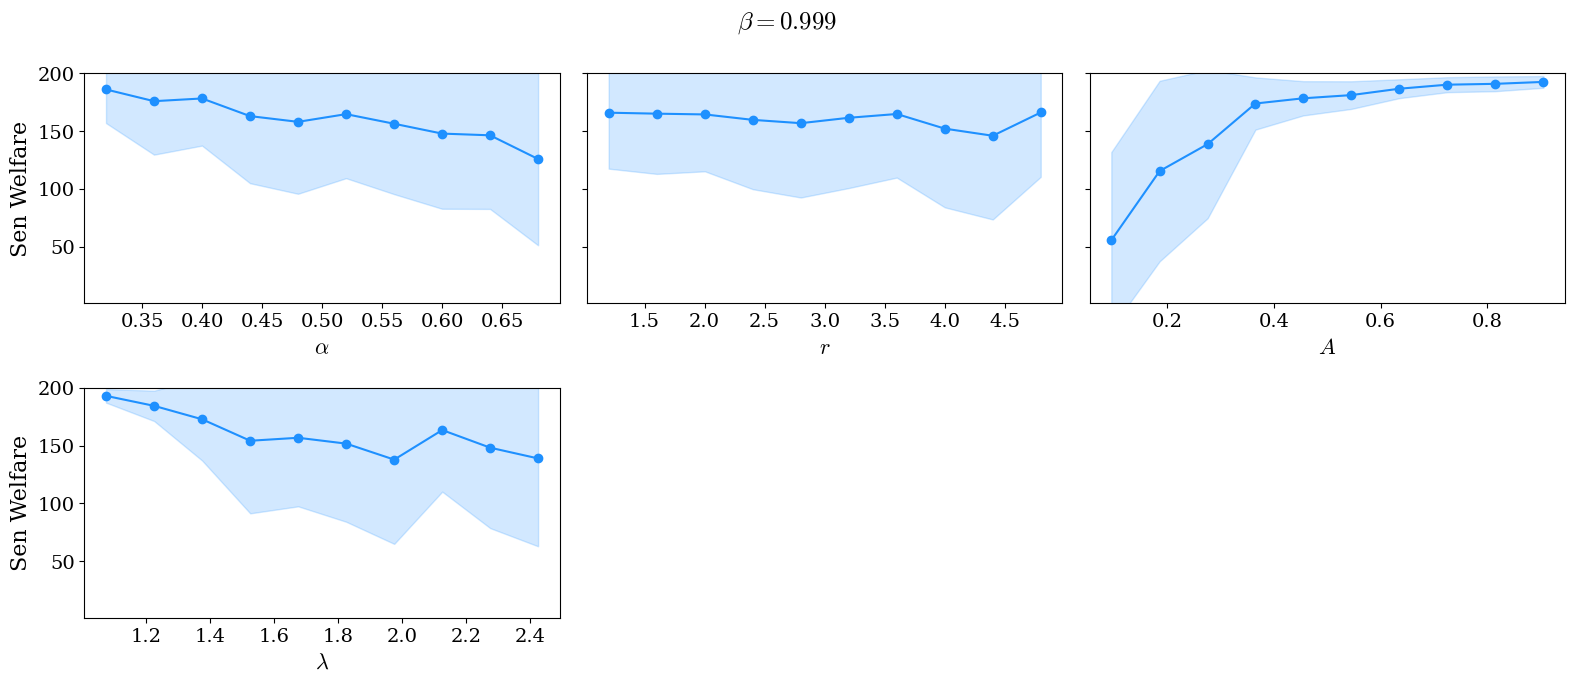

In [55]:
directory = "eut"
with open(f"../data/pt/pt_999/sen_welfare", "rb") as f:
    sen = pickle.load(f)

data = []
with open(f"../data/pt/pt_999/params", "rb") as f:
    P = pickle.load(f)
for i,row in enumerate(P):
    data.append((row[0], row[1], row[2], row[3], sen[i]))


cols = ["alpha", "rate", "A", "lambda", "welfare"]
df = pd.DataFrame(data, columns=cols)

nbins = 10
labels = [r"$\alpha$", r"$r$", r"$A$", r"$\lambda$"]
fig, axs = plt.subplots(2, 3, figsize=(16,7), sharey=True)
for i,param in enumerate(cols[:-1]):
    df["bin"] = pd.cut(df[param], bins=nbins)
    group = df.groupby("bin")["welfare"]
    mean_vals = group.mean()
    std_vals = group.std()
    bin_centers = [interval.mid for interval in mean_vals.index]
    axs[int(i/3)][i%3].plot(bin_centers, mean_vals.values, label="Mean Sen Welfare", color="dodgerblue", marker="o")
    axs[int(i/3)][i%3].fill_between(bin_centers,
                    mean_vals - std_vals,
                    mean_vals + std_vals,
                    alpha=0.2,
                    label="± 1 std",
                    color="dodgerblue"
    )
    axs[int(i/3)][i%3].set_xlabel(labels[i])
    axs[int(i/3)][i%3].set_ylim(1,200)

axs[0][0].set_ylabel("Sen Welfare")
axs[1][0].set_ylabel("Sen Welfare")
axs[1][2].set_visible(False)
axs[1][1].set_visible(False)

plt.suptitle(r"$\beta=0.999$")
fig.tight_layout()
#plt.savefig(f"../figures/{directory}_sen_welfare.pdf", bbox_inches="tight")
plt.show()

# EUT

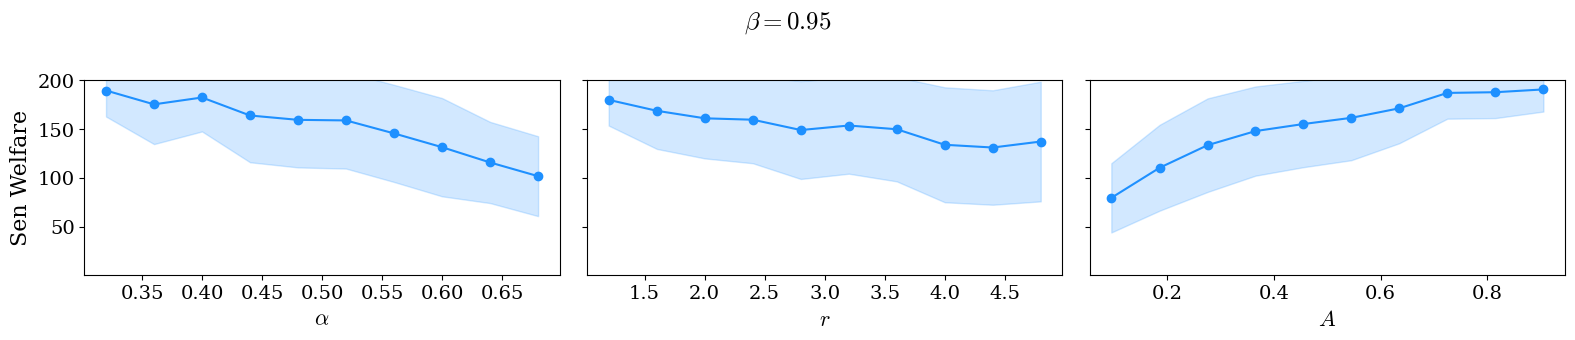

In [49]:
directory = "eut"
with open(f"../data/eut/eut_95/sen_welfare", "rb") as f:
    sen = pickle.load(f)

data = []
with open(f"../data/eut/eut_95/params", "rb") as f:
    P = pickle.load(f)
for i,row in enumerate(P):
    data.append((row[0], row[1], row[2], sen[i]))

cols = ["alpha", "rate", "A", "welfare"]
df = pd.DataFrame(data, columns=cols)

nbins = 10
labels = [r"$\alpha$", r"$r$", r"$A$"]
fig, axs = plt.subplots(1, 3, figsize=(16,3.5), sharey=True)
for i,param in enumerate(cols[:-1]):
    df["bin"] = pd.cut(df[param], bins=nbins)
    group = df.groupby("bin")["welfare"]
    mean_vals = group.mean()
    std_vals = group.std()
    bin_centers = [interval.mid for interval in mean_vals.index]
    axs[i].plot(bin_centers, mean_vals.values, label="Mean Sen Welfare", color="dodgerblue", marker='o')
    axs[i].fill_between(bin_centers,
                    mean_vals - std_vals,
                    mean_vals + std_vals,
                    alpha=0.2,
                    label="± 1 std",
                    color="dodgerblue"
    )
    axs[i].set_xlabel(labels[i])
    axs[i].set_ylim(1,200)

axs[0].set_ylabel("Sen Welfare")
plt.suptitle(r"$\beta=0.95$")
fig.tight_layout()
#plt.savefig(f"../figures/{directory}_sen_welfare.pdf", bbox_inches="tight")
plt.show()

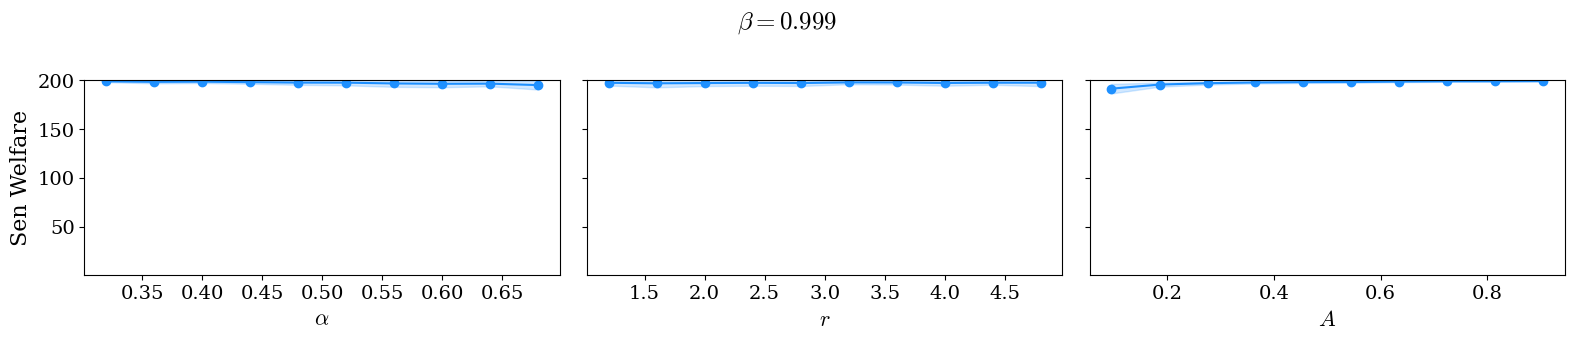

In [48]:
directory = "eut"
with open(f"../data/eut/eut_999/sen_welfare", "rb") as f:
    sen = pickle.load(f)

data = []
with open(f"../data/eut/eut_999/params", "rb") as f:
    P = pickle.load(f)
for i,row in enumerate(P):
    data.append((row[0], row[1], row[2], sen[i]))

cols = ["alpha", "rate", "A", "welfare"]
df = pd.DataFrame(data, columns=cols)

nbins = 10
labels = [r"$\alpha$", r"$r$", r"$A$", r"$s$"]
fig, axs = plt.subplots(1, 3, figsize=(16,3.5), sharey=True)
for i,param in enumerate(cols[:-1]):
    df["bin"] = pd.cut(df[param], bins=nbins)
    group = df.groupby("bin")["welfare"]
    mean_vals = group.mean()
    std_vals = group.std()
    bin_centers = [interval.mid for interval in mean_vals.index]
    axs[i].plot(bin_centers, mean_vals.values, label="Mean Sen Welfare", color="dodgerblue", marker='o')
    axs[i].fill_between(bin_centers,
                    mean_vals - std_vals,
                    mean_vals + std_vals,
                    alpha=0.2,
                    label="± 1 std",
                    color="dodgerblue"
    )
    axs[i].set_xlabel(labels[i])
    axs[i].set_ylim(1,200)

axs[0].set_ylabel("Sen Welfare")
plt.suptitle(r"$\beta=0.999$")
fig.tight_layout()
#plt.savefig(f"../figures/{directory}_sen_welfare.pdf", bbox_inches="tight")
plt.show()

# KDEs

##### $\beta=0.95$

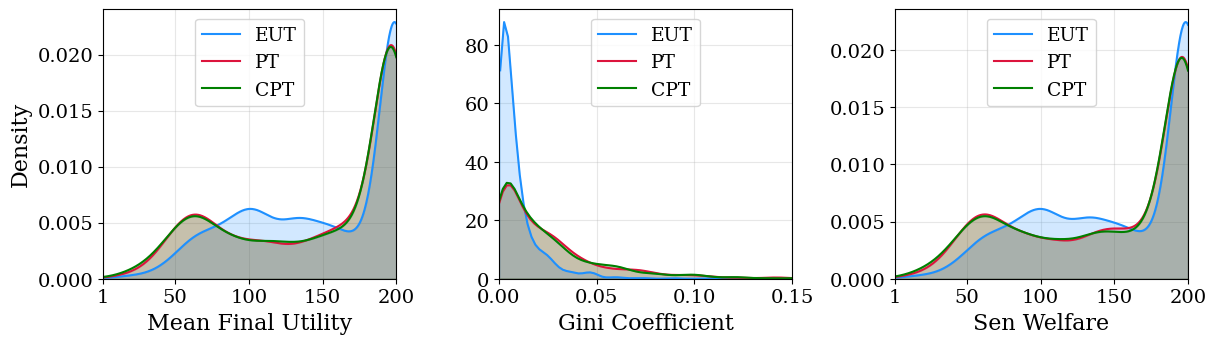

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(14,3.5))
labels = ["EUT", "PT", "CPT"]
colors = ["dodgerblue", "crimson", "green"]

# Mean Final Utility
beta = "95"
cpt_func = "kt"

directories = [f"../data/eut/eut_{beta}", f"../data/pt/pt_{beta}", f"../data/cpt/cpt_kt_{beta}"]

for i, directory in enumerate(directories):
    with open(f"{directory}/mean_util", "rb") as f:
        M = pickle.load(f)
    kde = gaussian_kde(M, bw_method=0.2)
    x_vals = np.linspace(1, 200, 500)
    y_vals = kde(x_vals)
    y_vals /= np.trapz(y_vals, x_vals)
    axs[0].plot(x_vals, y_vals, color=colors[i], label=labels[i], lw=1.5)
    axs[0].fill_between(x_vals, y_vals, color=colors[i], alpha=0.2)
axs[0].set_ylabel("Density")
axs[0].set_xlabel("Mean Final Utility")
axs[0].legend(loc="upper center")
axs[0].set_ylim(0,)
axs[0].set_xticks([1, 50, 100, 150, 200])
axs[0].grid()
axs[0].set_xlim(1,200)

# Gini Coefficient
for i, directory in enumerate(directories):
    with open(f"{directory}/gini", "rb") as f:
        G = pickle.load(f)
    kde = gaussian_kde(G, bw_method=0.2)
    x_vals = np.linspace(min(G), 1, 500)
    y_vals = kde(x_vals)
    y_vals /= np.trapz(y_vals, x_vals)
    axs[1].plot(x_vals, y_vals, color=colors[i], label=labels[i], lw=1.5)
    axs[1].fill_between(x_vals, y_vals, color=colors[i], alpha=0.2)
axs[1].set_xlabel("Gini Coefficient")
axs[1].legend(loc="upper center")
axs[1].set_xlim(0, 0.15)
axs[1].grid()
axs[1].set_ylim(0,)

# Sen Welfare
for i, directory in enumerate(directories):
    with open(f"{directory}/sen_welfare", "rb") as f:
        sen = pickle.load(f)
    kde = gaussian_kde(sen, bw_method=0.2)
    x_vals = np.linspace(1, 200, 500)
    y_vals = kde(x_vals)
    y_vals /= np.trapz(y_vals, x_vals)
    axs[2].plot(x_vals, y_vals, color=colors[i], label=labels[i], lw=1.5)
    axs[2].fill_between(x_vals, y_vals, color=colors[i], alpha=0.2)
axs[2].set_xlabel("Sen Welfare")
axs[2].set_xticks([1, 50, 100, 150, 200])
axs[2].legend(loc="upper center")
axs[2].grid()
axs[2].set_ylim(0,)
axs[2].set_xlim(1,200)

#plt.suptitle(r"$\beta=0.95$")

fig.subplots_adjust(wspace=0.35)
plt.savefig("../figures/util_gini_welfare_kde_comparison.pdf", bbox_inches="tight")
plt.show()

#### $\beta=0.999$

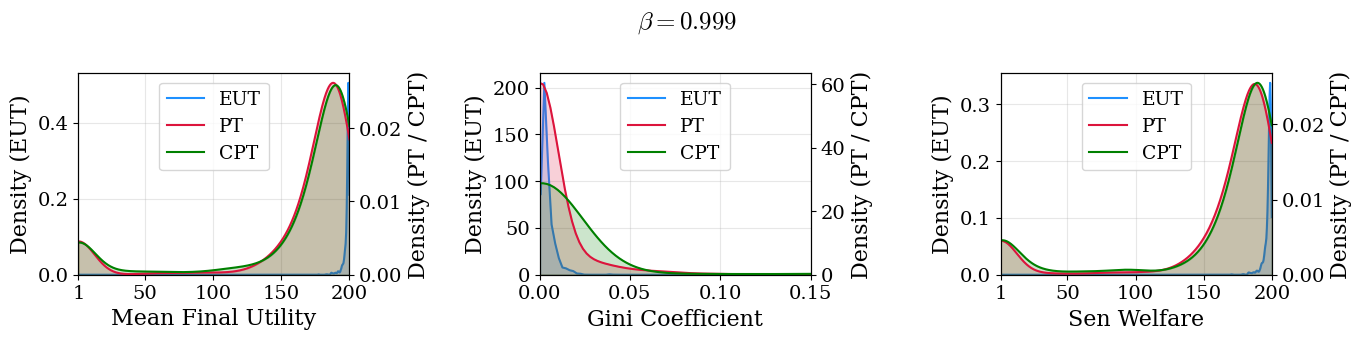

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(14, 3.5))
labels = ["EUT", "PT", "CPT"]
colors = ["dodgerblue", "crimson", "green"]

beta = "999"
cpt_func = "kt"

directories = [f"../data/eut/eut_{beta}", f"../data/pt/pt_{beta}", f"../data/cpt/cpt_kt_{beta}"]

# ── Mean Final Utility ──────────────────────────────────────────────────────
ax = axs[0]
ax_r = ax.twinx()

for i, directory in enumerate(directories):
    with open(f"{directory}/mean_util", "rb") as f:
        M = pickle.load(f)
    kde = gaussian_kde(M, bw_method=0.2)
    x_vals = np.linspace(1, 200, 500)
    y_vals = kde(x_vals)
    y_vals /= np.trapz(y_vals, x_vals)

    target_ax = ax if i == 0 else ax_r
    target_ax.plot(x_vals, y_vals, color=colors[i], label=labels[i], lw=1.5)
    target_ax.fill_between(x_vals, y_vals, color=colors[i], alpha=0.2)

ax.set_ylabel("Density (EUT)")
ax_r.set_ylabel("Density (PT / CPT)")
ax.tick_params(axis="y")
ax_r.tick_params(axis="y")
ax.set_xlabel("Mean Final Utility")
ax.set_ylim(0,)
ax_r.set_ylim(0,)
ax.set_xticks([1, 50, 100, 150, 200])
ax.set_xlim(1, 200)
ax.grid()

lines_l, labels_l = ax.get_legend_handles_labels()
lines_r, labels_r = ax_r.get_legend_handles_labels()
ax.legend(lines_l + lines_r, labels_l + labels_r, loc="upper center")

# ── Gini Coefficient ────────────────────────────────────────────────────────
ax = axs[1]
ax_r = ax.twinx()

all_G = []
for i, directory in enumerate(directories):
    with open(f"{directory}/gini", "rb") as f:
        G = pickle.load(f)
    all_G.append(G)

for i, G in enumerate(all_G):
    kde = gaussian_kde(G, bw_method=0.2)
    x_vals = np.linspace(min(G), 1, 500)
    y_vals = kde(x_vals)
    y_vals /= np.trapz(y_vals, x_vals)

    target_ax = ax if i == 0 else ax_r
    target_ax.plot(x_vals, y_vals, color=colors[i], label=labels[i], lw=1.5)
    target_ax.fill_between(x_vals, y_vals, color=colors[i], alpha=0.2)

ax.set_ylabel("Density (EUT)")
ax_r.set_ylabel("Density (PT / CPT)")
ax.tick_params(axis="y")
ax_r.tick_params(axis="y")
ax.set_xlabel("Gini Coefficient")
ax.set_xlim(0, 0.15)
ax.set_ylim(0,)
ax_r.set_ylim(0,)
ax.grid()

lines_l, labels_l = ax.get_legend_handles_labels()
lines_r, labels_r = ax_r.get_legend_handles_labels()
ax.legend(lines_l + lines_r, labels_l + labels_r, loc="upper center")

# ── Sen Welfare ─────────────────────────────────────────────────────────────
ax = axs[2]
ax_r = ax.twinx()

for i, directory in enumerate(directories):
    with open(f"{directory}/sen_welfare", "rb") as f:
        sen = pickle.load(f)
    kde = gaussian_kde(sen, bw_method=0.2)
    x_vals = np.linspace(1, 200, 500)
    y_vals = kde(x_vals)
    y_vals /= np.trapz(y_vals, x_vals)

    target_ax = ax if i == 0 else ax_r
    target_ax.plot(x_vals, y_vals, color=colors[i], label=labels[i], lw=1.5)
    target_ax.fill_between(x_vals, y_vals, color=colors[i], alpha=0.2)

ax.set_ylabel("Density (EUT)")
ax_r.set_ylabel("Density (PT / CPT)")
ax.tick_params(axis="y")
ax_r.tick_params(axis="y")
ax.set_xlabel("Sen Welfare")
ax.set_xticks([1, 50, 100, 150, 200])
ax.set_xlim(1, 200)
ax.set_ylim(0,)
ax_r.set_ylim(0,)
ax.grid()

lines_l, labels_l = ax.get_legend_handles_labels()
lines_r, labels_r = ax_r.get_legend_handles_labels()
ax.legend(lines_l + lines_r, labels_l + labels_r, loc="upper center")

plt.suptitle(r"$\beta=0.999$")
fig.tight_layout()
# plt.savefig("../figures/util_gini_welfare_kde_comparison_revised.pdf", bbox_inches="tight")
plt.show()


# Pairwise EUT vs. PT vs. CPT Comparison

#### $\beta=0.95$

In [7]:
beta = "95"

directories = [f"../data/eut/eut_{beta}", f"../data/pt/pt_{beta}", f"../data/cpt/cpt_kt_{beta}"]

eut_data = []
with open(f"../data/eut/eut_{beta}/params", "rb") as f:
    P = pickle.load(f)
for row in P:
    eut_data.append((row[0], row[1], row[2], 1, 1))
with open(f"../data/eut/eut_{beta}/sen_welfare", "rb") as f:
    eut_sen = pickle.load(f)

pt_data = []
with open(f"../data/pt/pt_{beta}/params", "rb") as f:
    P = pickle.load(f)
for row in P:
    pt_data.append((row[0], row[1], row[2], row[3], 1))
with open(f"../data/pt/pt_{beta}/sen_welfare", "rb") as f:
    pt_sen = pickle.load(f)

cpt_data = []
with open(f"../data/cpt/cpt_kt_{beta}/params", "rb") as f:
    P = pickle.load(f)
for row in P:
    cpt_data.append((row[0], row[1], row[2], row[3], row[4]))
with open(f"../data/cpt/cpt_kt_{beta}/sen_welfare", "rb") as f:
    cpt_sen = pickle.load(f)

cpt_data, cpt_sen = zip(*sorted(zip(cpt_data, cpt_sen)))
pt_data, pt_sen = zip(*sorted(zip(pt_data, pt_sen)))
eut_data, eut_sen = zip(*sorted(zip(eut_data, eut_sen)))

1.3460798064600718e-93
1.0572175634598789e-23


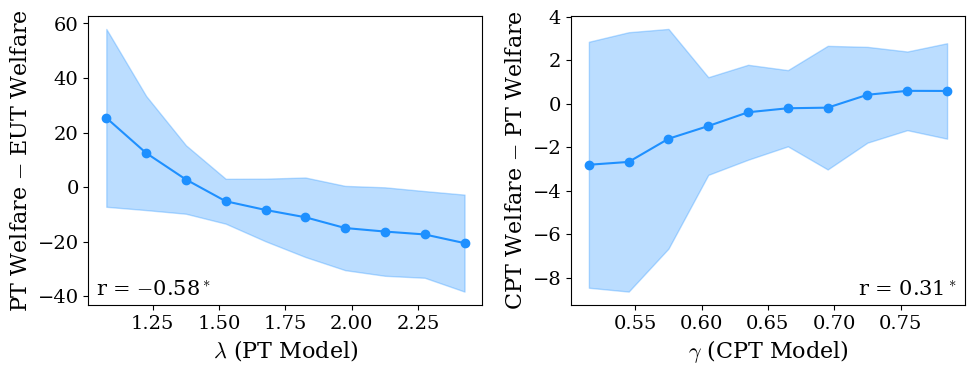

In [9]:
N = 10
fig, axs = plt.subplots(1, 2, figsize=(10,4))

pt_lambda = [pt_data[i][3] for i in range(len(pt_data))]
pt_eut_sen = [pt_sen[i] - eut_sen[i] for i in range(len(pt_sen))]
pt_lambda = np.array(pt_lambda)
pt_eut_sen = np.array(pt_eut_sen)
bins = np.linspace(pt_lambda.min(), pt_lambda.max(), N+1)
bin_centers = []
means = []
stds = []
for i in range(N):
    left, right = bins[i], bins[i+1]
    mask = (pt_lambda >= left) & (pt_lambda < right)
    if np.any(mask):
        bin_centers.append((left + right) / 2)
        means.append(np.mean(pt_eut_sen[mask]))
        stds.append(np.std(pt_eut_sen[mask]))
    else:
        bin_centers.append((left + right) / 2)
        means.append(np.nan)
        stds.append(np.nan)
bin_centers = np.array(bin_centers)
means = np.array(means)
stds = np.array(stds)
axs[0].plot(bin_centers, means, color="dodgerblue", marker="o")
axs[0].fill_between(bin_centers, means - stds, means + stds, alpha=0.3, color="dodgerblue")
axs[0].set_xlabel(r"$\lambda$ (PT Model)")
axs[0].set_ylabel(r"PT Welfare $-$ EUT Welfare")
r_pt, p1 = pearsonr(pt_lambda, pt_eut_sen)
print(p1)
r_pt = str(round(r_pt, 2))[1:]
axs[0].text(
    0.02, 0.02,
    "r = " + r"$-$" + r_pt + r"$^*$",
    ha="left", va="bottom",
    transform=axs[0].transAxes
)


cpt_gamma = [cpt_data[i][-1] for i in range(len(cpt_data))]
cpt_pt_sen = [cpt_sen[i] - pt_sen[i] for i in range(len(pt_sen))]
cpt_gamma = np.array(cpt_gamma)
cpt_pt_sen = np.array(cpt_pt_sen)
bins = np.linspace(cpt_gamma.min(), cpt_gamma.max(), N+1)
bin_centers = []
means = []
stds = []
for i in range(N):
    left, right = bins[i], bins[i+1]
    mask = (cpt_gamma >= left) & (cpt_gamma < right)
    if np.any(mask):
        bin_centers.append((left + right) / 2)
        means.append(np.mean(cpt_pt_sen[mask]))
        stds.append(np.std(cpt_pt_sen[mask]))
    else:
        bin_centers.append((left + right) / 2)
        means.append(np.nan)
        stds.append(np.nan)
bin_centers = np.array(bin_centers)
means = np.array(means)
stds = np.array(stds)
axs[1].plot(bin_centers, means, color="dodgerblue", marker="o")
axs[1].fill_between(bin_centers, means - stds, means + stds, alpha=0.3, color="dodgerblue")
axs[1].set_xlabel(r"$\gamma$ (CPT Model)")
axs[1].set_ylabel(r"CPT Welfare $-$ PT Welfare")
r_cpt, p2 = pearsonr(cpt_gamma, cpt_pt_sen)
print(p2)
r_cpt = str(round(r_cpt, 2))
axs[1].text(
    0.98, 0.02,
    "r = " + r_cpt + r"$^*$",
    ha="right", va="bottom",
    transform=axs[1].transAxes
)
fig.tight_layout()
plt.savefig("../figures/gamma_lambda_correlation_welfare.pdf", bbox_inches="tight")
plt.show()

#### $\beta=0.999$

In [40]:
beta = "999"

directories = [f"../data/eut/eut_{beta}", f"../data/pt/pt_{beta}", f"../data/cpt/cpt_kt_{beta}"]

eut_data = []
with open(f"../data/eut/eut_{beta}/params", "rb") as f:
    P = pickle.load(f)
for row in P:
    eut_data.append((row[0], row[1], row[2], 1, 1))
with open(f"../data/eut/eut_{beta}/sen_welfare", "rb") as f:
    eut_sen = pickle.load(f)

pt_data = []
with open(f"../data/pt/pt_{beta}/params", "rb") as f:
    P = pickle.load(f)
for row in P:
    pt_data.append((row[0], row[1], row[2], row[3], 1))
with open(f"../data/pt/pt_{beta}/sen_welfare", "rb") as f:
    pt_sen = pickle.load(f)

cpt_data = []
with open(f"../data/cpt/cpt_kt_{beta}/params", "rb") as f:
    P = pickle.load(f)
for row in P:
    cpt_data.append((row[0], row[1], row[2], row[3], row[4]))
with open(f"../data/cpt/cpt_kt_{beta}/sen_welfare", "rb") as f:
    cpt_sen = pickle.load(f)

cpt_data, cpt_sen = zip(*sorted(zip(cpt_data, cpt_sen)))
pt_data, pt_sen = zip(*sorted(zip(pt_data, pt_sen)))
eut_data, eut_sen = zip(*sorted(zip(eut_data, eut_sen)))

1.184260446543375e-16
0.0015002113682821747


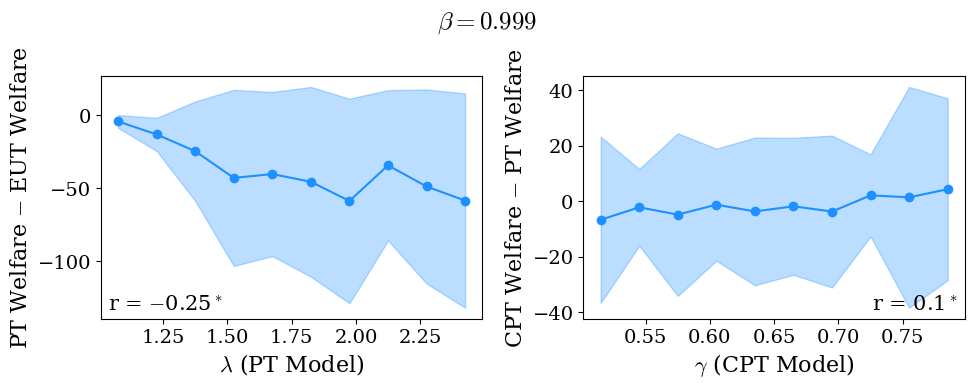

In [42]:
N = 10
fig, axs = plt.subplots(1, 2, figsize=(10,4))

pt_lambda = [pt_data[i][3] for i in range(len(pt_data))]
pt_eut_sen = [pt_sen[i] - eut_sen[i] for i in range(len(pt_sen))]
pt_lambda = np.array(pt_lambda)
pt_eut_sen = np.array(pt_eut_sen)
bins = np.linspace(pt_lambda.min(), pt_lambda.max(), N+1)
bin_centers = []
means = []
stds = []
for i in range(N):
    left, right = bins[i], bins[i+1]
    mask = (pt_lambda >= left) & (pt_lambda < right)
    if np.any(mask):
        bin_centers.append((left + right) / 2)
        means.append(np.mean(pt_eut_sen[mask]))
        stds.append(np.std(pt_eut_sen[mask]))
    else:
        bin_centers.append((left + right) / 2)
        means.append(np.nan)
        stds.append(np.nan)
bin_centers = np.array(bin_centers)
means = np.array(means)
stds = np.array(stds)
axs[0].plot(bin_centers, means, color="dodgerblue", marker="o")
axs[0].fill_between(bin_centers, means - stds, means + stds, alpha=0.3, color="dodgerblue")
axs[0].set_xlabel(r"$\lambda$ (PT Model)")
axs[0].set_ylabel(r"PT Welfare $-$ EUT Welfare")
r_pt, p1 = pearsonr(pt_lambda, pt_eut_sen)
print(p1)
r_pt = str(round(r_pt, 2))[1:]
axs[0].text(
    0.02, 0.02,
    "r = " + r"$-$" + r_pt + r"$^*$",
    ha="left", va="bottom",
    transform=axs[0].transAxes
)


cpt_gamma = [cpt_data[i][-1] for i in range(len(cpt_data))]
cpt_pt_sen = [cpt_sen[i] - pt_sen[i] for i in range(len(pt_sen))]
cpt_gamma = np.array(cpt_gamma)
cpt_pt_sen = np.array(cpt_pt_sen)
bins = np.linspace(cpt_gamma.min(), cpt_gamma.max(), N+1)
bin_centers = []
means = []
stds = []
for i in range(N):
    left, right = bins[i], bins[i+1]
    mask = (cpt_gamma >= left) & (cpt_gamma < right)
    if np.any(mask):
        bin_centers.append((left + right) / 2)
        means.append(np.mean(cpt_pt_sen[mask]))
        stds.append(np.std(cpt_pt_sen[mask]))
    else:
        bin_centers.append((left + right) / 2)
        means.append(np.nan)
        stds.append(np.nan)
bin_centers = np.array(bin_centers)
means = np.array(means)
stds = np.array(stds)
axs[1].plot(bin_centers, means, color="dodgerblue", marker="o")
axs[1].fill_between(bin_centers, means - stds, means + stds, alpha=0.3, color="dodgerblue")
axs[1].set_xlabel(r"$\gamma$ (CPT Model)")
axs[1].set_ylabel(r"CPT Welfare $-$ PT Welfare")
r_cpt, p2 = pearsonr(cpt_gamma, cpt_pt_sen)
print(p2)
r_cpt = str(round(r_cpt, 2))
axs[1].text(
    0.98, 0.02,
    "r = " + r_cpt + r"$^*$",
    ha="right", va="bottom",
    transform=axs[1].transAxes
)
plt.suptitle(r"$\beta=0.999$")
fig.tight_layout()
#plt.savefig("../figures/gamma_lambda_correlation_welfare_revised.png", bbox_inches="tight")
plt.show()